In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from astropy.io import fits
import matplotlib.animation as animation 
from tqdm import tqdm
plt.rcParams['figure.dpi'] = 400
os.chdir('/Users/ainsleylewis/glafic2')

Processing frames:   0%|          | 0/200 [00:00<?, ?it/s]
glafic  ver. 2.1.10 (2024.10.02) by Masamune Oguri

######## parameter definition
omega    =  3.000000e-01
lambda   =  7.000000e-01
weos     =  -1.000000e+00
hubble   =  7.000000e-01
prefix   =  /Users/ainsleylewis/Documents/Astronomy/TestLens/out/bh
xmin     =  -1.000000e+01
ymin     =  -1.000000e+01
xmax     =  1.000000e+01
ymax     =  1.000000e+01
pix_ext  =  1.000000e-02
nx_ext   =  2000
ny_ext   =  2000
pix_poi  =  1.000000e+00
nx_poi   =  20
ny_poi   =  20
maxlev   =  1

flag_extnorm    =  1
obs_gain        =  3.000000e+00
obs_ncomb       =  3
obs_readnoise   =  1.000000e+01
flag_srcsbin    =  1

######## startup
lens   point   0.3000  1.000000e+11  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00 
extend sersic  0.4000  5.000000e+10  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  8.000000e+00  4.000000e+00 
psf  8.000000e-01  2.000000e-02 -4.500000e+01  5.000000e+00  8.000000e-0

KeyboardInterrupt: 

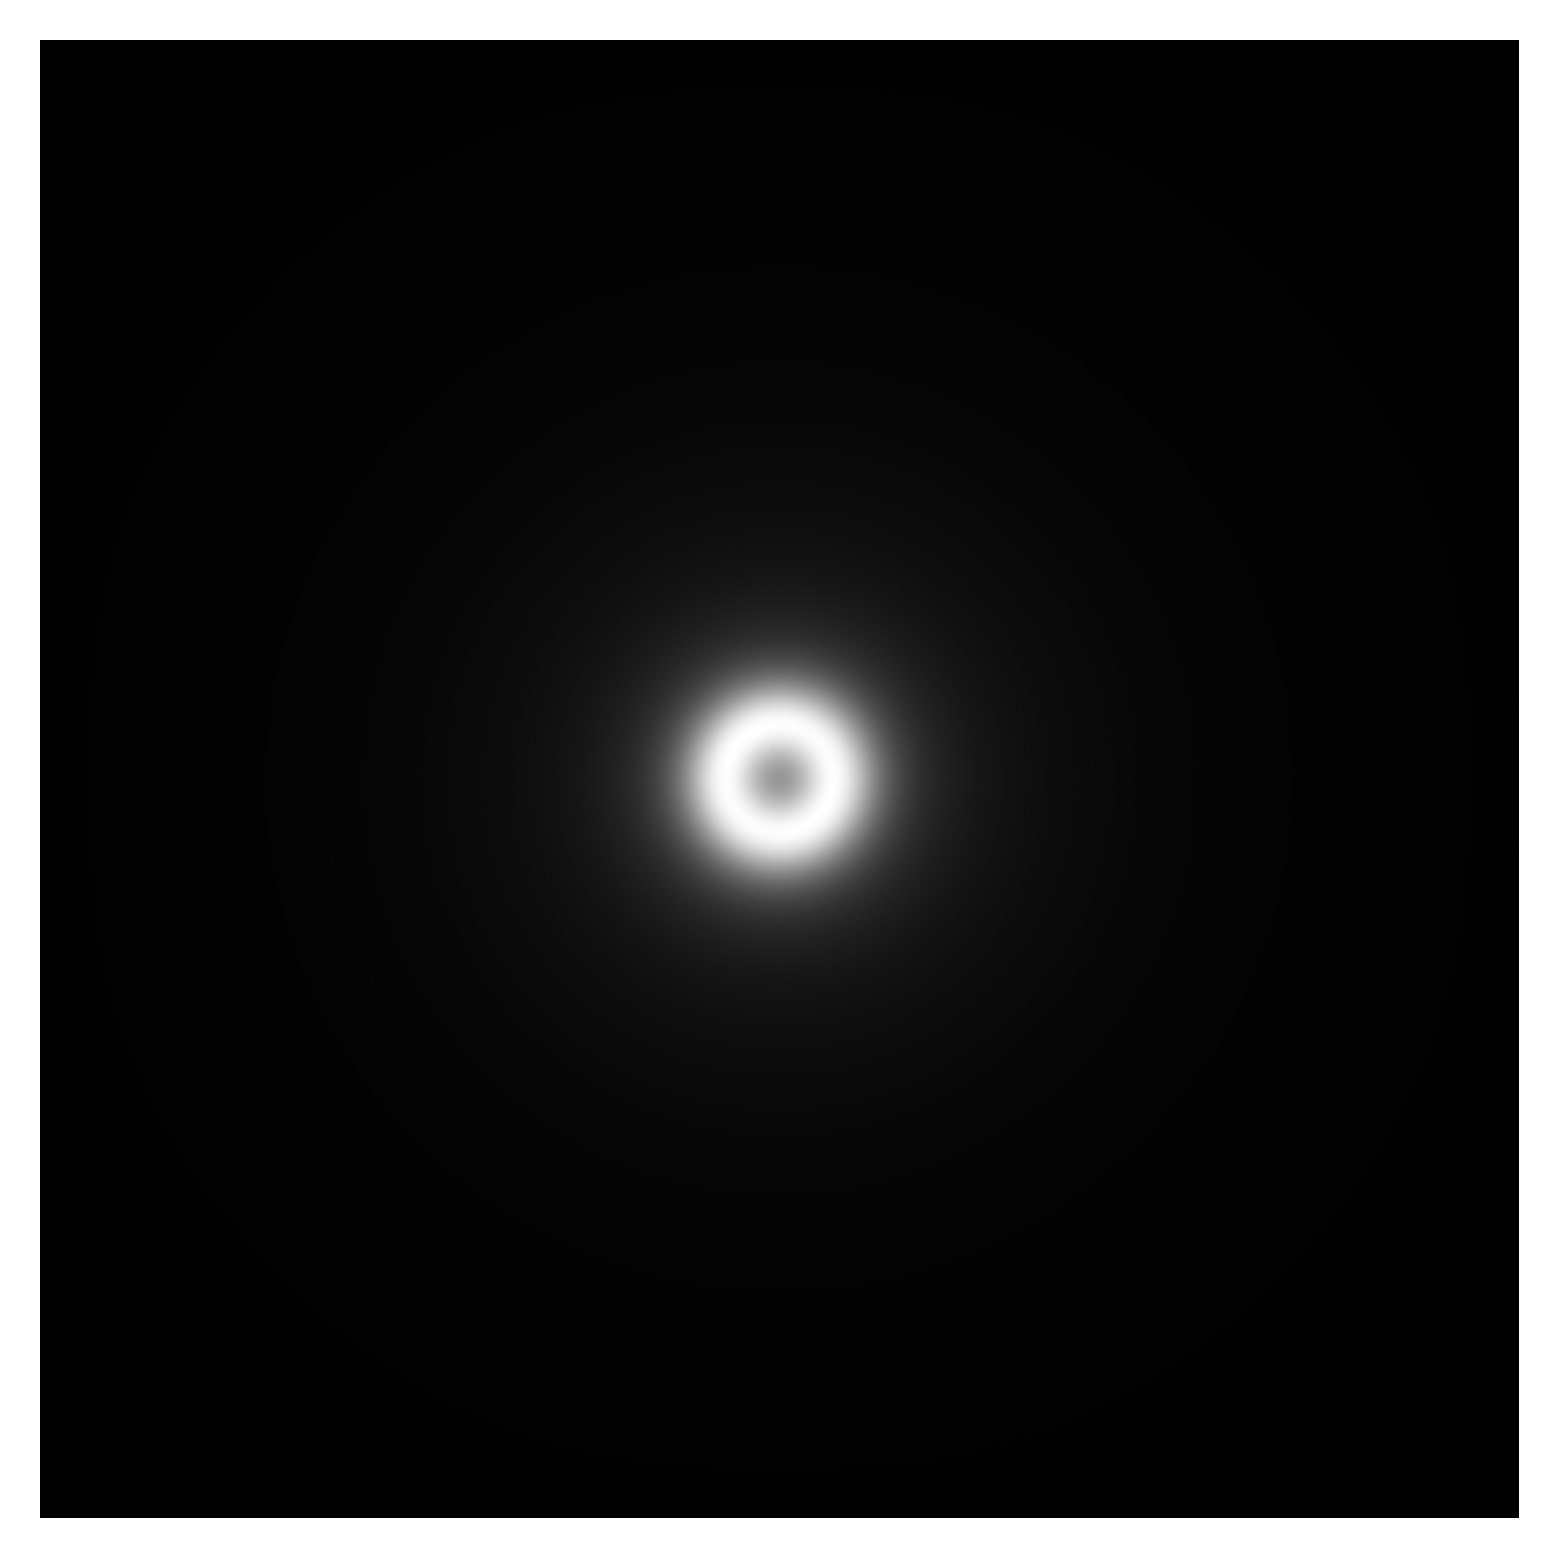

In [16]:
input_path = '/Users/ainsleylewis/Documents/Astronomy/TestLens/input/bh.input'
m = np.linspace(0.4, 2.5, 200)

for i in tqdm(range(len(m)), desc="Processing frames"):
    with open(input_path, 'r') as fin:
        lines = fin.readlines()

    with open(input_path, 'w') as fout:
        for line in lines:
            if line.startswith('extend sersic'):
                parts = line.split()
                parts[2] = str(m[i])  # Replace the 6th parameter (index 6) with pa
                fout.write(' '.join(parts) + '\n')
            else:
                fout.write(line)
    
    os.system('./glafic /Users/ainsleylewis/Documents/Astronomy/TestLens/input/bh.input')
    data = fits.open('/Users/ainsleylewis/Documents/Astronomy/TestLens/out/bh_image.fits')
    data = data[0].data

    plt.imshow(data, origin='lower', cmap='gray')
    plt.axis('off')
    plt.savefig(f'/Volumes/T7 Shield/Frames/frame_{i:03d}.png', bbox_inches='tight', pad_inches=0)
    plt.close()

In [14]:
import os
import subprocess

# --- Configuration ---
base_path = "/Volumes/T7 Shield/Frames/"
output_path = "/Users/ainsleylewis/Documents/Astronomy/TestLens/plots/bh"
fps = 30  # Frames per second (changeable)
output_format = "mp4"  # or "mov"
# ----------------------

# Input pattern for ffmpeg (zero-padded filenames like frame_000.png)
input_pattern = os.path.join(base_path, "frame_%03d.png")
output_file = f"{output_path}.{output_format}"

# Choose codec based on format
if output_format == "mp4":
    codec = "libx264"
elif output_format == "mov":
    codec = "prores_ks"  # high-quality Apple ProRes
else:
    raise ValueError("Unsupported format. Use 'mp4' or 'mov'.")

# ffmpeg command
command = [
    "ffmpeg", "-y",
    "-framerate", str(fps),
    "-i", input_pattern,
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
    "-c:v", codec,
    "-pix_fmt", "yuv420p",
    output_file
]


# Run ffmpeg
print("Running ffmpeg command:")
print(" ".join(command))
subprocess.run(command, check=True)

print(f"✅ Video created successfully: {output_file}")
print(f"FPS: {fps}, Format: {output_format}")


Running ffmpeg command:
ffmpeg -y -framerate 30 -i /Volumes/T7 Shield/Frames/frame_%03d.png -vf pad=ceil(iw/2)*2:ceil(ih/2)*2 -c:v libx264 -pix_fmt yuv420p /Users/ainsleylewis/Documents/Astronomy/TestLens/plots/bh.mp4


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

✅ Video created successfully: /Users/ainsleylewis/Documents/Astronomy/TestLens/plots/bh.mp4
FPS: 30, Format: mp4


[out#0/mp4 @ 0x157e24fa0] video:13KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 25.103926%
frame=  200 fps=0.0 q=-1.0 Lsize=      16KiB time=00:00:06.60 bitrate=  19.7kbits/s speed=18.4x    
[libx264 @ 0x157e25f10] frame I:1     Avg QP:17.65  size:   812
[libx264 @ 0x157e25f10] frame P:54    Avg QP:15.40  size:   110
[libx264 @ 0x157e25f10] frame B:145   Avg QP:13.71  size:    38
[libx264 @ 0x157e25f10] consecutive B-frames:  2.0%  3.0%  3.0% 92.0%
[libx264 @ 0x157e25f10] mb I  I16..4: 18.6% 80.9%  0.5%
[libx264 @ 0x157e25f10] mb P  I16..4:  0.1%  0.1%  0.0%  P16..4:  5.2%  0.9%  0.4%  0.0%  0.0%    skip:93.2%
[libx264 @ 0x157e25f10] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  2.6%  0.0%  0.0%  direct: 0.0%  skip:97.4%  L0:37.9% L1:62.1% BI: 0.0%
[libx264 @ 0x157e25f10] 8x8 transform intra:76.9% inter:99.5%
[libx264 @ 0x157e25f10] coded y,uvDC,uvAC intra: 7.4% 0.0% 0.0% inter: 0.1% 0.0% 0.0%
[libx264 @ 0x157e25f10] i16 v,h,dc,p: 19% 27%  8% 46%
[lib